# 03 — 1D SELFIES Transformer (standalone ablation)

Trains the SELFIES-only model: `SMILES -> SELFIES -> tokens -> Transformer -> mean-pool -> classifier head`.
This is the **1D-only** row in the final ablation table.

Doesn't depend on notebook 2 (conformers) at all.

In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import yaml
import torch
from torch.utils.data import DataLoader

from src.utils import load_json, save_json, set_seed
from src.featurizers import smiles_to_selfies, build_vocab, PAD
from src.datasets import SelfiesDataset
from src.models import Selfies1DModel
from src.train_utils import train_binary_classifier, evaluate

with open("../config/model_1d.yaml") as f:
    cfg = yaml.safe_load(f)

set_seed(cfg["train"]["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
cfg


c:\Users\ajaya\anaconda3\envs\chemprop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


{'model': {'d_model': 128,
  'n_heads': 4,
  'n_layers': 4,
  'd_ff': 256,
  'dropout': 0.1,
  'max_len': 128},
 'train': {'batch_size': 32,
  'lr': 0.0003,
  'weight_decay': 1e-05,
  'epochs': 60,
  'patience': 10,
  'seed': 42},
 'paths': {'splits_file': '../data/splits.json',
  'vocab_file': '../data/processed/selfies_vocab.json',
  'experiment_dir': '../experiments/1d_only'}}

## Load split, convert SMILES -> SELFIES

Same `splits.json` used everywhere.

In [2]:
splits = load_json(cfg["paths"]["splits_file"])

selfies_by_split = {}
for split_name in ["train", "valid", "test"]:
    smiles_list = splits[split_name]["smiles"]
    selfies_list = [smiles_to_selfies(s) for s in smiles_list]
    failed = [s for s, sf in zip(smiles_list, selfies_list) if sf is None]
    if failed:
        print(f"WARNING: {len(failed)} SMILES failed SELFIES encoding in {split_name}: {failed}")
    selfies_by_split[split_name] = selfies_list

print({k: len(v) for k, v in selfies_by_split.items()})


{'train': 453, 'valid': 66, 'test': 132}


## Build vocab from train split only

In [3]:
vocab = build_vocab(selfies_by_split["train"])
print(f"Vocab size: {len(vocab)}")

save_json(vocab, cfg["paths"]["vocab_file"])

# quick check: how many valid/test tokens are OOV (mapped to <UNK>)? Worth knowing, not necessarily fixing.
from src.featurizers import selfies_to_tokens
for split_name in ["valid", "test"]:
    oov = 0
    total = 0
    for s in selfies_by_split[split_name]:
        for tok in selfies_to_tokens(s):
            total += 1
            if tok not in vocab:
                oov += 1
    print(f"{split_name}: {oov}/{total} tokens OOV ({oov/total:.2%})")


Vocab size: 63
valid: 0/3116 tokens OOV (0.00%)
test: 6/5671 tokens OOV (0.11%)


## Datasets and dataloaders

In [4]:
datasets = {
    split_name: SelfiesDataset(
        selfies_by_split[split_name], splits[split_name]["y"], vocab, cfg["model"]["max_len"]
    )
    for split_name in ["train", "valid", "test"]
}

loaders = {
    "train": DataLoader(datasets["train"], batch_size=cfg["train"]["batch_size"], shuffle=True),
    "valid": DataLoader(datasets["valid"], batch_size=cfg["train"]["batch_size"], shuffle=False),
    "test":  DataLoader(datasets["test"],  batch_size=cfg["train"]["batch_size"], shuffle=False),
}

batch = next(iter(loaders["train"]))
print({k: v.shape if hasattr(v, 'shape') else v for k, v in batch.items()})


{'input_ids': torch.Size([32, 128]), 'length': torch.Size([32]), 'label': torch.Size([32])}


## Model, forward_fn, train

`forward_fn` is the only modality-specific piece — everything else (optimizer, early stopping, logging) comes from the shared `train_binary_classifier` in `src/train_utils.py`, reused unchanged by every later ablation.

In [5]:
model = Selfies1DModel(
    vocab_size=len(vocab), pad_id=vocab[PAD],
    d_model=cfg["model"]["d_model"], n_heads=cfg["model"]["n_heads"],
    n_layers=cfg["model"]["n_layers"], d_ff=cfg["model"]["d_ff"],
    dropout=cfg["model"]["dropout"], max_len=cfg["model"]["max_len"],
)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {n_params:,}")

def forward_fn(model, batch, device):
    return model(batch["input_ids"].to(device))


Model params: 562,689


In [6]:
model, train_info = train_binary_classifier(
    model, loaders["train"], loaders["valid"], forward_fn, cfg, cfg["paths"]["experiment_dir"], device
)
train_info


c:\Users\ajaya\anaconda3\envs\chemprop\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\bld\libtorch_1780241954714\work\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


epoch   1  train_loss=0.6049  val_loss=0.5112  val_auroc=0.8088
epoch   2  train_loss=0.5254  val_loss=0.4556  val_auroc=0.8325
epoch   3  train_loss=0.5487  val_loss=0.4432  val_auroc=0.8187
epoch   4  train_loss=0.5016  val_loss=0.4510  val_auroc=0.8462
epoch   5  train_loss=0.4375  val_loss=0.4163  val_auroc=0.8413
epoch   6  train_loss=0.4079  val_loss=0.4304  val_auroc=0.8162
epoch   7  train_loss=0.4095  val_loss=0.3952  val_auroc=0.8250
epoch   8  train_loss=0.3667  val_loss=0.4055  val_auroc=0.8262
epoch   9  train_loss=0.3555  val_loss=0.4134  val_auroc=0.8150
epoch  10  train_loss=0.2863  val_loss=0.4479  val_auroc=0.8200
epoch  11  train_loss=0.3776  val_loss=0.4542  val_auroc=0.8125
epoch  12  train_loss=0.2729  val_loss=0.4431  val_auroc=0.8088
epoch  13  train_loss=0.2214  val_loss=0.5483  val_auroc=0.7762
epoch  14  train_loss=0.1924  val_loss=0.5121  val_auroc=0.7913
Early stopping at epoch 14 (no val AUROC improvement for 10 epochs)


{'best_val_auroc': 0.84625, 'epochs_trained': 14}

## Internal validation performance

**Not** the final held-out test number — this is what goes in the ablation table alongside 2D-only, 3D-only, etc. The official test set is touched once, at the very end, in notebook 07.

In [7]:
val_metrics = evaluate(model, loaders["valid"], forward_fn, device)
print(f"1D-only val AUROC: {val_metrics['auroc']:.4f}")

save_json(
    {"model": "1d_only", **val_metrics, **train_info, "config": cfg},
    Path(cfg["paths"]["experiment_dir"]) / "metrics.json",
)


1D-only val AUROC: 0.8462


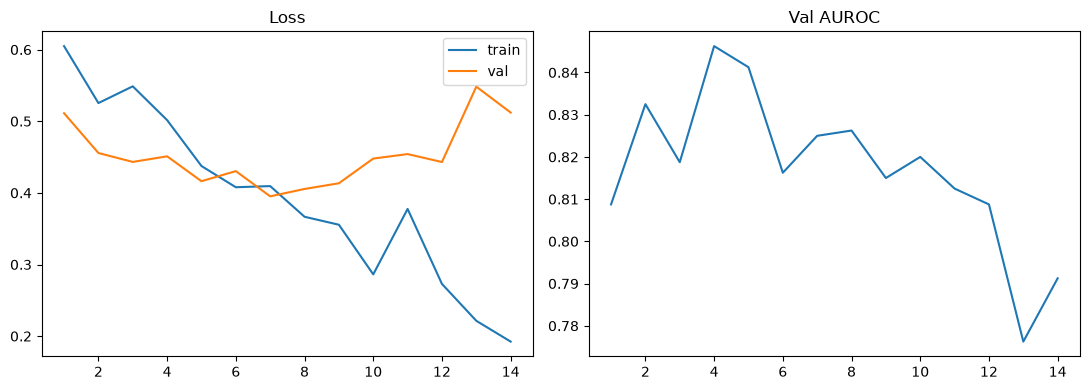

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

log = pd.read_csv(Path(cfg["paths"]["experiment_dir"]) / "train_log.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(log["epoch"], log["train_loss"], label="train")
axes[0].plot(log["epoch"], log["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(log["epoch"], log["val_auroc"])
axes[1].set_title("Val AUROC")
plt.tight_layout()
plt.show()
